# Load the dataset

In [ ]:
import pandas as pd

In [ ]:
train_df = pd.read_csv("train.txt", sep=';', names=["text", "label"], engine="python")
test_df = pd.read_csv("test.txt", sep=';', names=["text", "label"], engine="python")


In [ ]:
train_df['text'] = train_df['text'].str.strip()
train_df['label'] = train_df['label'].str.strip()

test_df['text'] = test_df['text'].str.strip()
test_df['label'] = test_df['label'].str.strip()


In [ ]:
# Look how the data looks like
print("Train set shape:", train_df.shape)
print(train_df.head(), "\n")
print("Train label distribution:\n", train_df['label'].value_counts())

Train set shape: (16000, 2)
                                                text    label
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger 

Train label distribution:
 label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


In [ ]:
# we can see that joy and sadness count the most in this dataset
# the top 3 emotions are negative > positive

# Preprocess - Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Encode labels = integers
le = LabelEncoder()
train_df['label_enc'] = le.fit_transform(train_df['label'])
test_df['label_enc'] = le.transform(test_df['label'])

In [ ]:
# Check
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_mapping)

Label mapping: {'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}


In [ ]:
# ok now we can see that all the label changed into int

# FCNN

In [ ]:
# TfidVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_df['text']).toarray()
X_test = vectorizer.transform(test_df['text']).toarray()

y_train = train_df['label_enc'].values
y_test = test_df['label_enc'].values

print("TF-IDF shape (train):", X_train.shape)
print("TF-IDF shape (test):", X_test.shape)


TF-IDF shape (train): (16000, 5000)
TF-IDF shape (test): (2000, 5000)


In [ ]:
# ok now we can see that the max feature is now 5000

We choose TfidVectorizer is becasue this is faster comparing to Word2Vec

FCNN model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [ ]:
# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [ ]:
class FCNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(FCNN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            # nn.Dropout(0.3),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.fc(x)

In [ ]:
input_dim = X_train.shape[1]
num_classes = len(label_mapping)
model = FCNN(input_dim, num_classes).to(device)

Train the model

In [ ]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Training loop
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

Epoch 1/5, Loss: 346.9822
Epoch 2/5, Loss: 152.5523
Epoch 3/5, Loss: 71.9759
Epoch 4/5, Loss: 46.9320
Epoch 5/5, Loss: 34.3919


Evaluate the model

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Evaluation
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))



Classification Report:
              precision    recall  f1-score   support

       anger       0.88      0.89      0.88       275
        fear       0.88      0.82      0.85       224
         joy       0.89      0.92      0.90       695
        love       0.75      0.74      0.74       159
     sadness       0.92      0.92      0.92       581
    surprise       0.73      0.67      0.70        66

    accuracy                           0.88      2000
   macro avg       0.84      0.82      0.83      2000
weighted avg       0.88      0.88      0.88      2000



In [ ]:
history = {
    "loss": [],
    "accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

from sklearn.metrics import accuracy_score
import numpy as np

for epoch in range(epochs):
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

    train_acc = accuracy_score(all_targets, all_preds)

    # Evaluate on test set for validation
    model.eval()
    val_loss = 0
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_targets, val_preds)

    # Save history
    history["loss"].append(total_loss / len(train_loader))
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss / len(test_loader))
    history["val_accuracy"].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f} - Acc: {train_acc:.4f} - Val_Loss: {val_loss:.4f} - Val_Acc: {val_acc:.4f}")


Epoch 1/5 - Loss: 26.2376 - Acc: 0.9731 - Val_Loss: 10.0113 - Val_Acc: 0.8795
Epoch 2/5 - Loss: 21.1998 - Acc: 0.9794 - Val_Loss: 10.2173 - Val_Acc: 0.8765
Epoch 3/5 - Loss: 17.6389 - Acc: 0.9833 - Val_Loss: 10.5079 - Val_Acc: 0.8770
Epoch 4/5 - Loss: 14.8619 - Acc: 0.9862 - Val_Loss: 10.5653 - Val_Acc: 0.8775
Epoch 5/5 - Loss: 12.7320 - Acc: 0.9883 - Val_Loss: 10.8110 - Val_Acc: 0.8750


In [ ]:
# PyTorch doesn’t return .history like Keras
# So we need to manually collect loss/accuracy per epoch

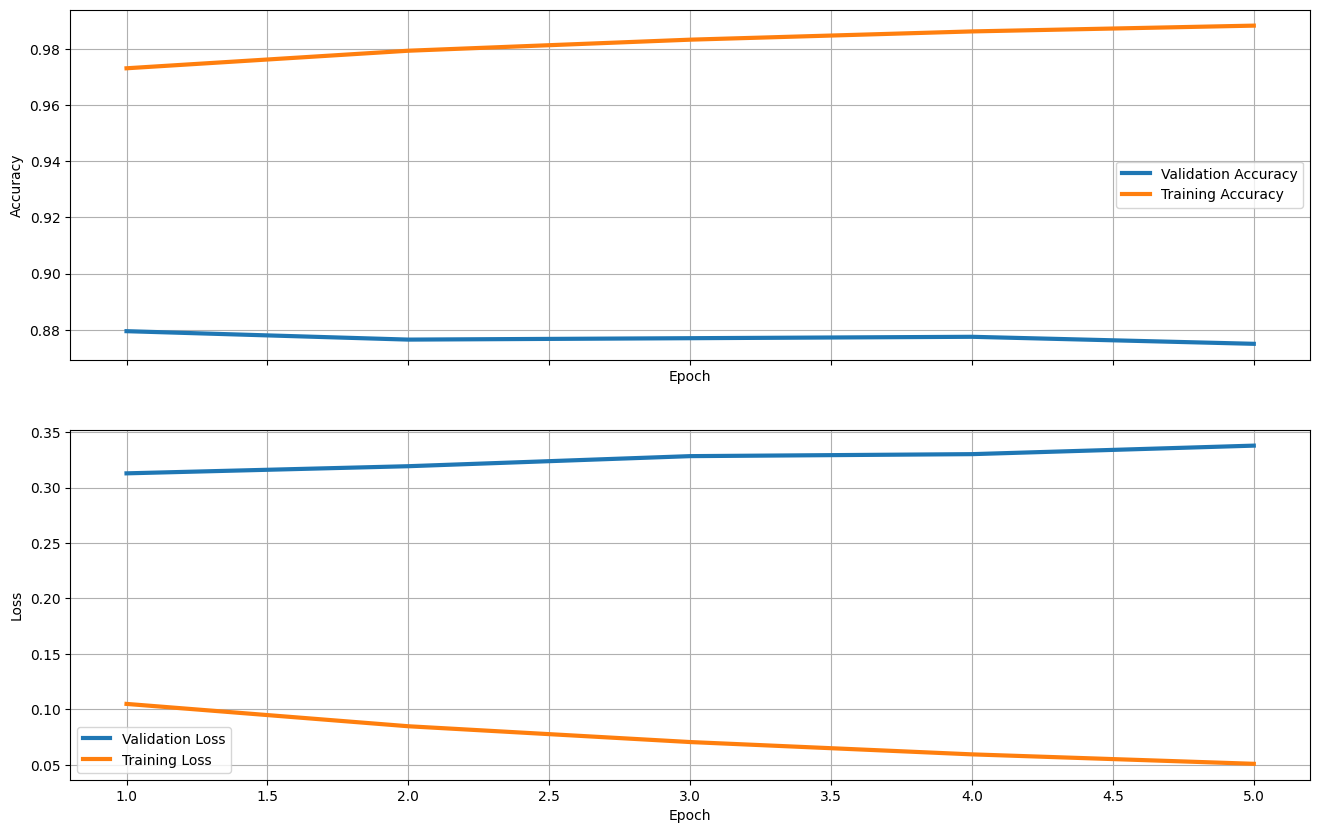

In [ ]:
import matplotlib.pyplot as plt

def plot_results(history):
    hist_df = pd.DataFrame(history)
    hist_df.columns=["loss", "accuracy", "val_loss", "val_accuracy"]
    hist_df.index = np.arange(1, len(hist_df)+1)

    fig, axs = plt.subplots(nrows=2, sharex=True, figsize=(16, 10))
    axs[0].plot(hist_df.val_accuracy, lw=3, label='Validation Accuracy')
    axs[0].plot(hist_df.accuracy, lw=3, label='Training Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].grid()
    axs[0].legend(loc=0)
    axs[1].plot(hist_df.val_loss, lw=3, label='Validation Loss')
    axs[1].plot(hist_df.loss, lw=3, label='Training Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].grid()
    axs[1].legend(loc=0)

    plt.show()

plot_results(history)

# RNN - LSTM

Tokenize + Padding

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# Combine train and test data for consistent tokenization
all_texts = train_df['text'].tolist() + test_df['text'].tolist()

In [ ]:
# Tokenize
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(all_texts)

In [ ]:
# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(train_df['text'].tolist())
X_test_seq = tokenizer.texts_to_sequences(test_df['text'].tolist())

In [ ]:
# Pad sequences
max_len = 50  # adjust based on dataset
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')


In [ ]:
y_train = train_df['label_enc'].values
y_test = test_df['label_enc'].values


LSTM model

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        out = self.dropout(hidden[-1])
        return self.fc(out)


Preperation

In [ ]:
# Convert data
X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


In [ ]:
# DataLoader
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
vocab_size = 10000
embed_dim = 128
hidden_dim = 128
output_dim = len(label_mapping)

model = LSTMModel(vocab_size, embed_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


Evaluation

In [ ]:
# Training setup
epochs = 15
history = {
    "loss": [],
    "accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(epochs):
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

    train_acc = accuracy_score(all_targets, all_preds)

    # Validation
    model.eval()
    val_loss = 0
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_targets, val_preds)

    # Log epoch results
    history["loss"].append(total_loss / len(train_loader))
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss / len(test_loader))
    history["val_accuracy"].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f} - Acc: {train_acc:.4f} - Val_Loss: {val_loss:.4f} - Val_Acc: {val_acc:.4f}")


Epoch 1/15 - Loss: 399.0559 - Acc: 0.3157 - Val_Loss: 50.2032 - Val_Acc: 0.3455
Epoch 2/15 - Loss: 395.7112 - Acc: 0.3311 - Val_Loss: 50.0414 - Val_Acc: 0.3475
Epoch 3/15 - Loss: 395.1127 - Acc: 0.3283 - Val_Loss: 50.1832 - Val_Acc: 0.3465
Epoch 4/15 - Loss: 393.6123 - Acc: 0.3366 - Val_Loss: 50.0610 - Val_Acc: 0.3475
Epoch 5/15 - Loss: 392.8235 - Acc: 0.3362 - Val_Loss: 50.1585 - Val_Acc: 0.3475
Epoch 6/15 - Loss: 388.6259 - Acc: 0.3416 - Val_Loss: 48.3644 - Val_Acc: 0.2895
Epoch 7/15 - Loss: 333.3533 - Acc: 0.3873 - Val_Loss: 38.3275 - Val_Acc: 0.4305
Epoch 8/15 - Loss: 279.3487 - Acc: 0.4422 - Val_Loss: 35.8456 - Val_Acc: 0.4540
Epoch 9/15 - Loss: 252.3235 - Acc: 0.4809 - Val_Loss: 32.4799 - Val_Acc: 0.5015
Epoch 10/15 - Loss: 204.8608 - Acc: 0.6480 - Val_Loss: 22.7493 - Val_Acc: 0.7585
Epoch 11/15 - Loss: 110.8544 - Acc: 0.8556 - Val_Loss: 16.1236 - Val_Acc: 0.8390
Epoch 12/15 - Loss: 72.3711 - Acc: 0.9073 - Val_Loss: 14.7241 - Val_Acc: 0.8415
Epoch 13/15 - Loss: 54.8620 - Acc: 0.9

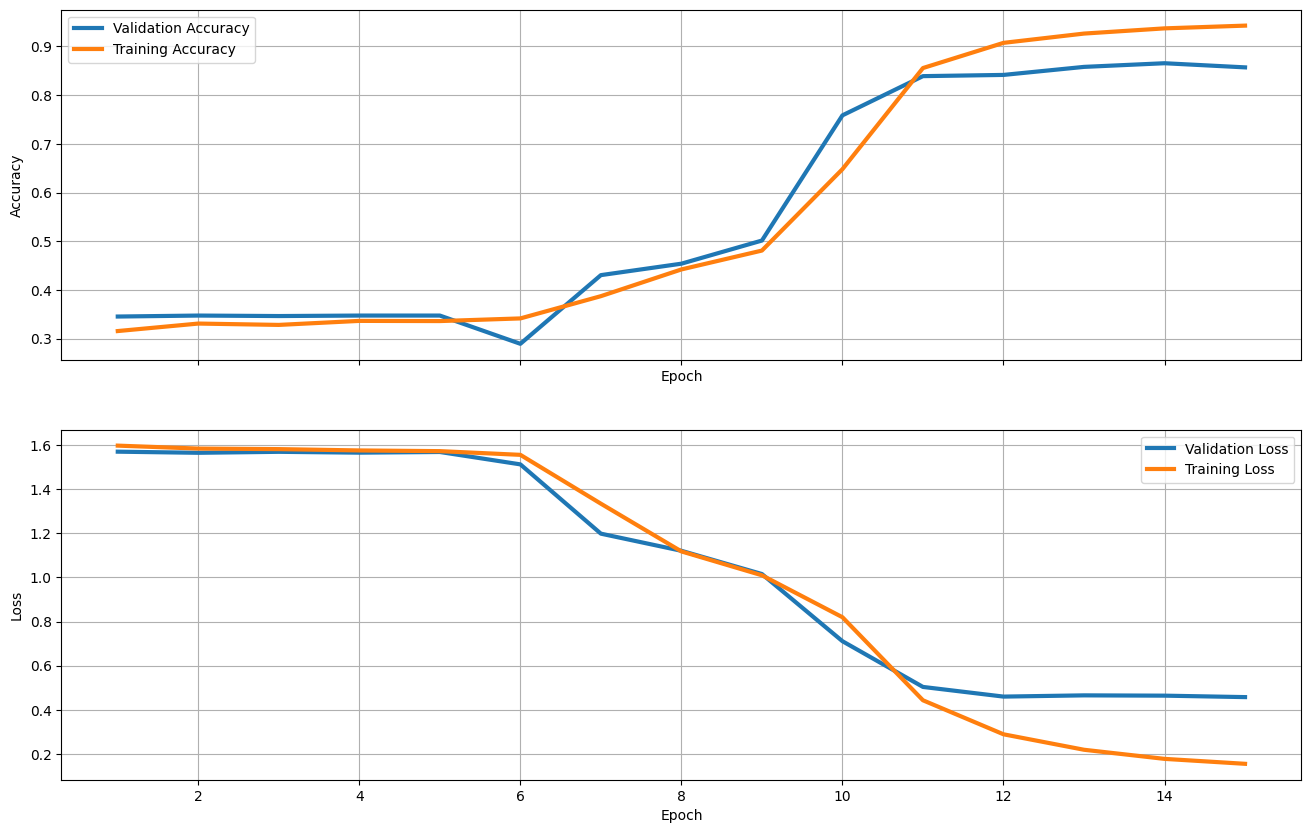

In [ ]:
def plot_results(history):
    hist_df = pd.DataFrame(history)
    hist_df.columns = ["loss", "accuracy", "val_loss", "val_accuracy"]
    hist_df.index = np.arange(1, len(hist_df) + 1)

    fig, axs = plt.subplots(nrows=2, sharex=True, figsize=(16, 10))
    axs[0].plot(hist_df.val_accuracy, lw=3, label='Validation Accuracy')
    axs[0].plot(hist_df.accuracy, lw=3, label='Training Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].grid()
    axs[0].legend(loc=0)
    axs[1].plot(hist_df.val_loss, lw=3, label='Validation Loss')
    axs[1].plot(hist_df.loss, lw=3, label='Training Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].grid()
    axs[1].legend(loc=0)

    plt.show()

plot_results(history)

# Transformer Model

In [ ]:
import pandas as pd
import torch
from transformers import DistilBertTokenizerFast
from torch.utils.data import Dataset

# Load data
train_df = pd.read_csv("train.txt", sep=';', names=["text", "label"], engine="python")
test_df = pd.read_csv("test.txt", sep=';', names=["text", "label"], engine="python")

# Clean
train_df['text'] = train_df['text'].str.strip()
train_df['label'] = train_df['label'].str.strip()
test_df['text'] = test_df['text'].str.strip()
test_df['label'] = test_df['label'].str.strip()

# Encode labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
train_df['label_enc'] = label_encoder.fit_transform(train_df['label'])
test_df['label_enc'] = label_encoder.transform(test_df['label'])


In [ ]:
# Define custom PyTorch Dataset
class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.encodings['input_ids'][idx]),
            'attention_mask': torch.tensor(self.encodings['attention_mask'][idx]),
            'labels': torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.labels)

In [ ]:
# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Tokenize text data
train_encodings = tokenizer(train_df['text'].tolist(), truncation=True, padding='max_length', max_length=128)
test_encodings = tokenizer(test_df['text'].tolist(), truncation=True, padding='max_length', max_length=128)

# Create datasets
train_dataset = TweetDataset(train_encodings, train_df['label_enc'].tolist())
test_dataset = TweetDataset(test_encodings, test_df['label_enc'].tolist())

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments

!pip install datasets --quiet  # If not already installed
from datasets import load_metric

accuracy_metric = load_metric("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    return {"accuracy": acc["accuracy"]}


# Disable wandb
import os
os.environ["WANDB_DISABLED"] = "true"

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_strategy="steps",    # Log every few steps
    logging_steps=10,
    save_strategy="no",
    report_to="none"
)


# Load model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(label_encoder.classes_)
    )

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,

)

trainer.train()


# Train
results = trainer.evaluate()
print("Test set results:", results)


/tmp/ipython-input-5-3588394560.py:6: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  accuracy_metric = load_metric("accuracy")


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
10,1.751900
20,1.647600
30,1.616400
40,1.598800
50,1.570400
60,1.534400
70,1.451600
80,1.287400
90,1.211600
100,1.198700


Test set results: {'eval_loss': 0.18369026482105255, 'eval_accuracy': 0.921, 'eval_runtime': 7.1806, 'eval_samples_per_second': 278.53, 'eval_steps_per_second': 4.456, 'epoch': 3.0}


In [ ]:

train_results = trainer.evaluate(eval_dataset=train_dataset)
print("Training set results:", train_results)

Training set results: {'eval_loss': 0.06903188675642014, 'eval_accuracy': 0.96975, 'eval_runtime': 58.6724, 'eval_samples_per_second': 272.701, 'eval_steps_per_second': 4.261, 'epoch': 3.0}


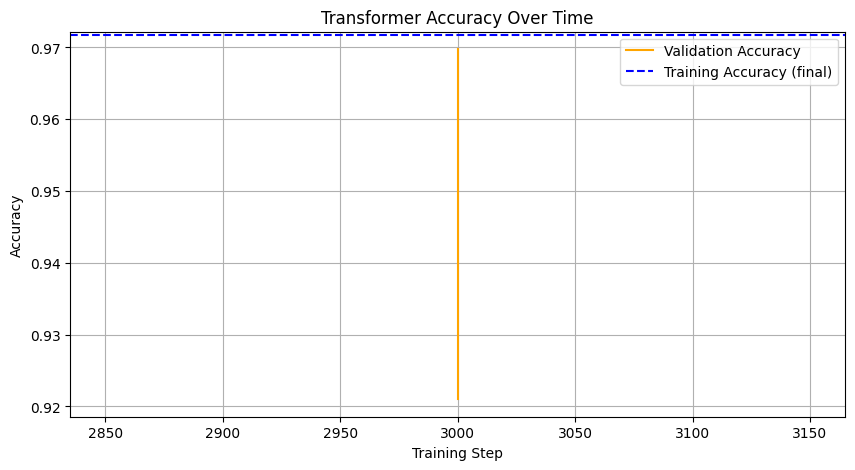

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

log_df = pd.DataFrame(trainer.state.log_history)

# Extract eval (validation) accuracy
eval_acc = log_df[['step', 'eval_accuracy']].dropna()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(eval_acc['step'], eval_acc['eval_accuracy'], label='Validation Accuracy', color='orange')

# Add final training accuracy as horizontal line
plt.axhline(y=0.9717, color='blue', linestyle='--', label='Training Accuracy (final)')  # Replace with your exact value

plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.title("Transformer Accuracy Over Time")
plt.legend()
plt.grid(True)
plt.show()


